In [36]:
from ml_recon.Models.fastMRI_unet import Unet
from torch.utils.data import DataLoader
from ml_recon.Transforms import (pad, combine_coil, toTensor, addChannels, 
                                   view_as_real, fft_2d, normalize, pad_recon, normalize_mean)
from ml_recon.Dataset.undersampled_slice_loader import UndersampledSliceDataset
from torchvision.transforms import Compose
import numpy as np
import torch
from ml_recon.Utils.collate_function import collate_fn
from datetime import datetime
from ml_recon.Utils.save_model import save_model
from ml_recon.Utils import combine_coils, image_slices

In [37]:
torch.manual_seed(0)
np.random.seed(0)

In [3]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('/home/kadotab/scratch/runs/' +  datetime.now().strftime("%Y%m%d-%H%M%S"))

In [3]:
%load_ext autoreload
%autoreload 2 

In [38]:
transforms = Compose(
    (
        pad((640, 320)),
        pad_recon((320, 320)), 
        fft_2d(axes=[-1, -2]),
        toTensor(),
        combine_coil(0, use_abs=True),
        addChannels(),
        normalize_mean(), 
    )
)
dataset = UndersampledSliceDataset('/home/kadotab/header.json', transforms=transforms, R=2)
dataloader = DataLoader(dataset, batch_size=1, collate_fn=collate_fn)
    

In [44]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [39]:
data = next(iter(dataloader))

In [42]:
data['undersampled'].shape

torch.Size([1, 1, 320, 320])

In [35]:
data['recon'].std()

tensor(1.0797)

In [45]:
model = Unet(1, 1, chans=32)
model.to(device)

Unet(
  (down_sample_layers): ModuleList(
    (0): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Dropout2d(p=0.0, inplace=False)
        (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (5): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (6): LeakyReLU(negative_slope=0.2, inplace=True)
        (7): Dropout2d(p=0.0, inplace=False)
      )
    )
    (1): ConvBlock(
      (layers): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (2): LeakyReLU(negative_slope=0.2, inplace=True)
        (3): Dropout2

In [9]:
checkpoint = torch.load('/home/kadotab/python/ml/ml_recon/Model_Weights/20230511-132439Unet.pt', map_location=device)
model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

In [22]:
loss_fn = torch.nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [8]:
optimizer.load_state_dict(checkpoint['optimizer'])

In [27]:
checkpoint2 = torch.load('/home/kadotab/python/fastMRI/fastmri_examples/unet/unet/unet_demo/checkpoints/epoch=29-step=103320.ckpt')

In [38]:
class temp(torch.nn.Module):
    def __init__(self, unet):
        super().__init__()
        self.unet = unet

    def forward(self, x):
        return self.unet(x)

In [39]:
testing = temp(model)

In [40]:
testing.load_state_dict(checkpoint2['state_dict'])

<All keys matched successfully>

In [43]:
testing.to(device)

temp(
  (unet): Unet(
    (down_sample_layers): ModuleList(
      (0): ConvBlock(
        (layers): Sequential(
          (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          (2): LeakyReLU(negative_slope=0.2, inplace=True)
          (3): Dropout2d(p=0.0, inplace=False)
          (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (5): InstanceNorm2d(32, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          (6): LeakyReLU(negative_slope=0.2, inplace=True)
          (7): Dropout2d(p=0.0, inplace=False)
        )
      )
      (1): ConvBlock(
        (layers): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
          (2): LeakyReLU(neg

In [41]:
model.load_state_dict(checkpoint2['state_dict'])

RuntimeError: Error(s) in loading state_dict for Unet:
	Missing key(s) in state_dict: "down_sample_layers.0.layers.0.weight", "down_sample_layers.0.layers.4.weight", "down_sample_layers.1.layers.0.weight", "down_sample_layers.1.layers.4.weight", "down_sample_layers.2.layers.0.weight", "down_sample_layers.2.layers.4.weight", "down_sample_layers.3.layers.0.weight", "down_sample_layers.3.layers.4.weight", "conv.layers.0.weight", "conv.layers.4.weight", "up_conv.0.layers.0.weight", "up_conv.0.layers.4.weight", "up_conv.1.layers.0.weight", "up_conv.1.layers.4.weight", "up_conv.2.layers.0.weight", "up_conv.2.layers.4.weight", "up_conv.3.0.layers.0.weight", "up_conv.3.0.layers.4.weight", "up_conv.3.1.weight", "up_conv.3.1.bias", "up_transpose_conv.0.layers.0.weight", "up_transpose_conv.1.layers.0.weight", "up_transpose_conv.2.layers.0.weight", "up_transpose_conv.3.layers.0.weight". 
	Unexpected key(s) in state_dict: "unet.down_sample_layers.0.layers.0.weight", "unet.down_sample_layers.0.layer

In [10]:
data = next(iter(dataloader))

In [11]:
output = model(data['undersampled'].to(device))

In [55]:
output_abs = testing(data['undersampled'][:, :, 160:-160, :].pow(2).sum(1, keepdim=True).sqrt().to(device))

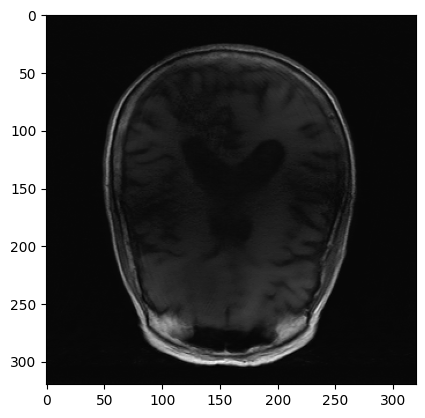

In [56]:
plt.imshow(output_abs[0, 0].detach().cpu(), cmap='gray')

In [70]:
output_abs2 = output.pow(2).sum(1).sqrt()

In [88]:
output_abs2.median()

tensor(0.0377, device='cuda:0', grad_fn=<MedianBackward0>)

In [89]:
output_abs.median()

tensor(-0.3761, device='cuda:0', grad_fn=<MedianBackward0>)

In [78]:
data['undersampled'].mean()

tensor(0.0193)

In [72]:
loss = loss_fn(output_abs2[0, 160:-160, :], data['recon'].to(device))

/home/kadotab/ENV/lib/python3.9/site-packages/torch/nn/modules/loss.py:101: UserWarning: Using a target size (torch.Size([1, 320, 320])) that is different to the input size (torch.Size([320, 320])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


In [73]:
loss.item()

0.04183750972151756

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

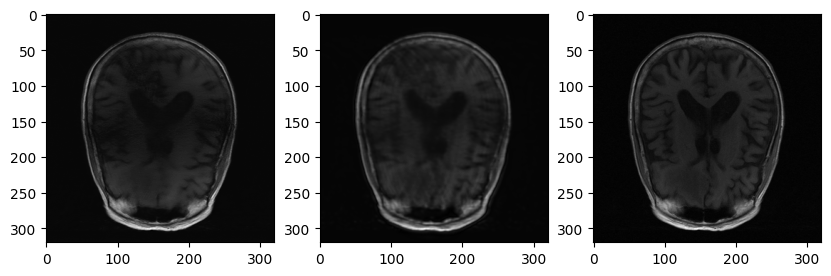

In [69]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(output_abs[0, 0].cpu().detach(), cmap='gray')
ax[1].imshow(output.pow(2).sum(1).sqrt()[0].cpu().detach()[160:-160], cmap='gray')
ax[2].imshow(data['recon'][0], cmap='gray')


In [64]:
diff = output_abs[:, 0, :, :].cpu() - data['recon'][:, :, :]

In [67]:
diff.abs().sum()/(320*320)

tensor(0.5784, grad_fn=<DivBackward0>)

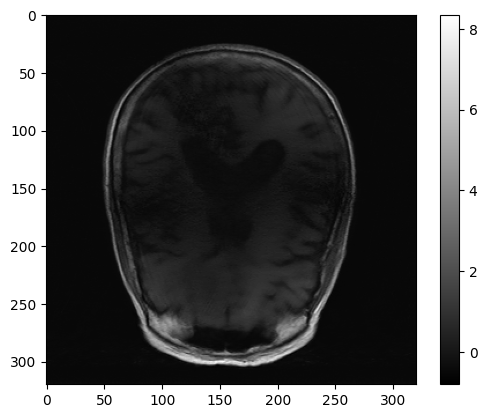

In [68]:
plt.imshow(diff[0, :, :].detach(), cmap='gray')
plt.colorbar()

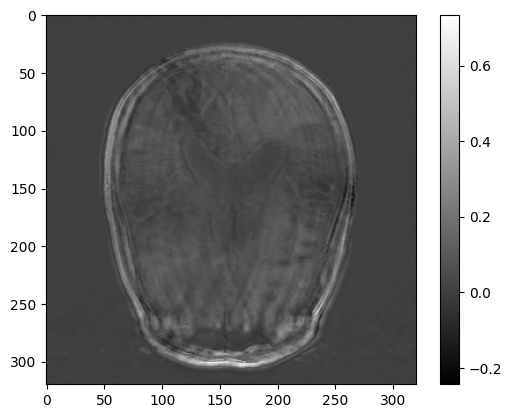

In [21]:
plt.imshow(diff[0, :, :].detach(), cmap='gray')
plt.colorbar()

In [11]:
import matplotlib.pyplot as plt

In [21]:
model_weight_path = '/home/kadotab/python/ml/ml_recon/Model_Weights/'
def train(model, loss_function, optimizer, dataloader, epoch=7):
    cur_loss = 0
    e = 0
    try:
        for e in range(epoch):
            for data in dataloader:
                undersampled = data['undersampled']
                recon = data['recon']
                optimizer.zero_grad()

                recon_slice = recon.to(device)
                undersampled = undersampled.to(device)
    
                predicted_sampled = model(undersampled)

                predicted_sampled = torch.sqrt(predicted_sampled.pow(2).sum(1)+ 1e-8)
                predicted_sampled = predicted_sampled[:, 160:-160, :]
                loss = loss_function(predicted_sampled, recon_slice)
                loss.backward()
                optimizer.step()
                    
                cur_loss += loss.item()
            writer.add_histogram('sens/weights1', model.down_sample_layers[0].conv1.weight, e)
            writer.add_histogram('castcade0/weights1', model.down_sample_layers[0].conv2.weight, e)
            writer.add_histogram('castcade0/weights2', model.down_sample_layers[3].conv.conv1.weight, e)
            writer.add_histogram('castcade0/weights11', model.up_sample_layers[3].conv.conv2.weight, e)
            writer.add_histogram('castcade0/weights12', model.conv1d.weight, e)
            writer.add_scalar('Loss/train', cur_loss, e)
            print(f"Iteration: {e + 1:>d}, Loss: {cur_loss:>7f}")
            save_model(model_weight_path, model, optimizer, e)
            cur_loss = 0
    except KeyboardInterrupt:
        pass

    save_model(model_weight_path, model, optimizer, -1)

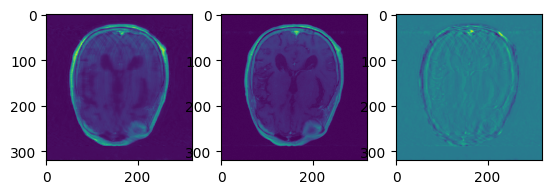

tensor(559632.1250, device='cuda:0', grad_fn=<PowBackward0>)
tensor(0.0008, device='cuda:0', grad_fn=<MseLossBackward0>)


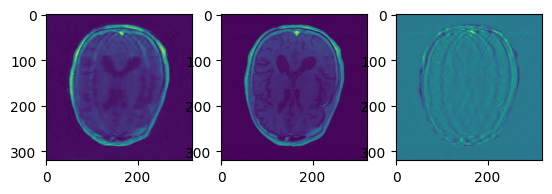

tensor(38275.2617, device='cuda:0', grad_fn=<PowBackward0>)
tensor(0.0009, device='cuda:0', grad_fn=<MseLossBackward0>)


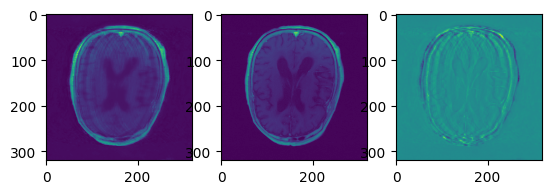

tensor(536763., device='cuda:0', grad_fn=<PowBackward0>)
tensor(0.0009, device='cuda:0', grad_fn=<MseLossBackward0>)


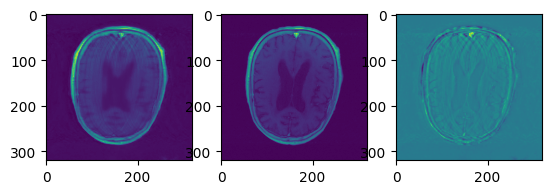

tensor(19788.3711, device='cuda:0', grad_fn=<PowBackward0>)
tensor(0.0006, device='cuda:0', grad_fn=<MseLossBackward0>)


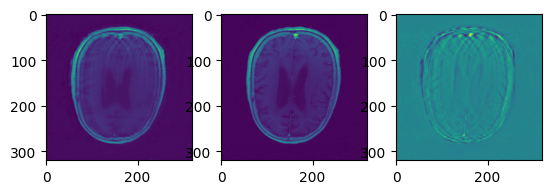

tensor(376270.9688, device='cuda:0', grad_fn=<PowBackward0>)
tensor(0.0006, device='cuda:0', grad_fn=<MseLossBackward0>)


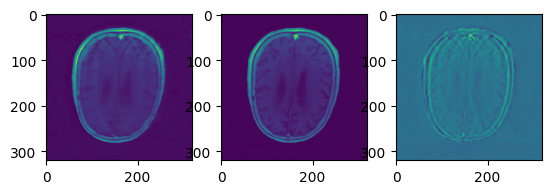

tensor(14625.2666, device='cuda:0', grad_fn=<PowBackward0>)
tensor(0.0006, device='cuda:0', grad_fn=<MseLossBackward0>)


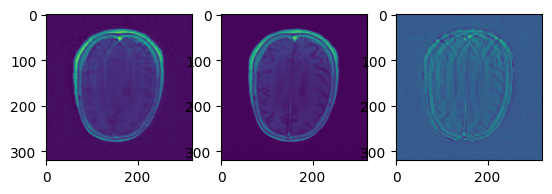

tensor(92790.8672, device='cuda:0', grad_fn=<PowBackward0>)
tensor(0.0006, device='cuda:0', grad_fn=<MseLossBackward0>)


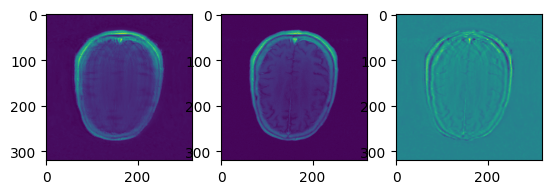

tensor(102724.2031, device='cuda:0', grad_fn=<PowBackward0>)
tensor(0.0008, device='cuda:0', grad_fn=<MseLossBackward0>)


In [22]:
train(model, loss_fn, optimizer, dataloader, epoch=50)